## 1. 📦 Installation & Setup

In [2]:
!pip install litellm -q
!pip install "litellm[proxy]" -q
!pip install "litellm[caching]" -q
!pip install langfuse redis -q

import litellm
import importlib.metadata

try:
    litellm_version = importlib.metadata.version("litellm")
    print(f"LiteLLM version: {litellm_version}")
except importlib.metadata.PackageNotFoundError:
    print("LiteLLM package not found.")
except Exception as e:
    print(f"Could not determine LiteLLM version: {e}")
print("Installation complete")

LiteLLM version: 1.82.0
Installation complete


## 2. 🔑 API Key Configuration
> Set only the keys you have. Each section marks which provider it needs.

In [4]:
import os

os.environ["OPENAI_API_KEY"]     = ""       # OpenAI

print("Keys configured (replace placeholders)")

Keys configured (replace placeholders)


## 3. 💬 Basic Completion — Multiple Providers
The same `litellm.completion()` call works for every provider.

In [6]:
from litellm import completion
import json

messages = [{"role": "user", "content": "What is the capital of France? One sentence."}]

# OpenAI
resp = completion(model="gpt-4o-mini", messages=messages)
print("OpenAI:", resp.choices[0].message.content)


OpenAI: The capital of France is Paris.


In [7]:
# Inspect the full OpenAI-compatible response object
print(json.dumps(resp.model_dump(), indent=2, default=str))

{
  "id": "chatcmpl-DHl8EQJxkOKVwX58ENfNuU63B6CSl",
  "created": 1773125122,
  "model": "gpt-4o-mini-2024-07-18",
  "object": "chat.completion",
  "system_fingerprint": "fp_1883e75a49",
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "message": {
        "content": "The capital of France is Paris.",
        "role": "assistant",
        "tool_calls": null,
        "function_call": null,
        "provider_specific_fields": {
          "refusal": null
        },
        "annotations": []
      },
      "provider_specific_fields": {}
    }
  ],
  "usage": {
    "completion_tokens": 7,
    "prompt_tokens": 17,
    "total_tokens": 24,
    "completion_tokens_details": {
      "accepted_prediction_tokens": 0,
      "audio_tokens": 0,
      "reasoning_tokens": 0,
      "rejected_prediction_tokens": 0
    },
    "prompt_tokens_details": {
      "audio_tokens": 0,
      "cached_tokens": 0
    }
  },
  "service_tier": "default"
}


## 4. ⚡ Streaming Responses

In [8]:
from litellm import completion

response = completion(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Write a 3-sentence story about a robot."}],
    stream=True,
)

print("Streaming: ", end="", flush=True)
full_text = ""
for chunk in response:
    delta = chunk.choices[0].delta.content or ""
    print(delta, end="", flush=True)
    full_text += delta
print("\n\nStream complete")

Streaming: In a quiet town, a small robot named Spark dreamed of becoming a painter, spending its days collecting vibrant leaves and fallen petals. One day, an art teacher noticed Spark's unique collection and decided to teach it how to blend colors and create masterpieces. With each stroke of its tiny robotic hands, Spark transformed the world around it, inspiring the townsfolk to see beauty in the simplest of things.

Stream complete


## 5. 🔄 Async Completions

In [9]:
import asyncio
from litellm import acompletion

async def async_demo():
    # Single async call
    resp = await acompletion(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": "What is 2+2?"}]
    )
    print("Single async:", resp.choices[0].message.content)

    # Parallel async calls
    prompts = ["Name a planet", "Name a fruit", "Name a color"]
    tasks = [
        acompletion(model="gpt-4o-mini", messages=[{"role": "user", "content": p}])
        for p in prompts
    ]
    results = await asyncio.gather(*tasks)
    print("\nParallel results:")
    for p, r in zip(prompts, results):
        print(f"  [{p}] -> {r.choices[0].message.content.strip()}")

await async_demo()

Single async: 2 + 2 equals 4.

Parallel results:
  [Name a planet] -> Mars.
  [Name a fruit] -> Apple.
  [Name a color] -> Turquoise.


In [10]:
from litellm import acompletion

async def async_stream_demo():
    response = await acompletion(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": "Count from 1 to 5, one number per line."}],
        stream=True,
    )
    print("Async stream: ", end="")
    async for chunk in response:
        delta = chunk.choices[0].delta.content or ""
        print(delta, end="", flush=True)
    print()

await async_stream_demo()

Async stream: 1  
2  
3  
4  
5  


## 6. 🧮 Embedding Generation

In [11]:
from litellm import embedding
import numpy as np

texts = ["Hello world", "Machine learning is fascinating", "Python programming"]
response = embedding(model="text-embedding-3-small", input=texts)

print(f"Model: {response.model}")
print(f"Embeddings: {len(response.data)}")
print(f"Dimensions: {len(response.data[0]['embedding'])}")

def cosine_sim(a, b):
    a, b = np.array(a), np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

sim = cosine_sim(response.data[0]["embedding"], response.data[1]["embedding"])
print(f"\nCosine sim ({texts[0]} | {texts[1]}): {sim:.4f}")

# Cohere (uncomment)
# response = embedding(model="cohere/embed-english-v3.0", input=texts, input_type="search_document")

Model: text-embedding-3-small
Embeddings: 3
Dimensions: 1536

Cosine sim (Hello world | Machine learning is fascinating): 0.2245


## 7. 🎨 Image Generation (DALL-E)

URL: https://oaidalleapiprodscus.blob.core.windows.net/private/org-8zakUdos59hjsrBCoP...


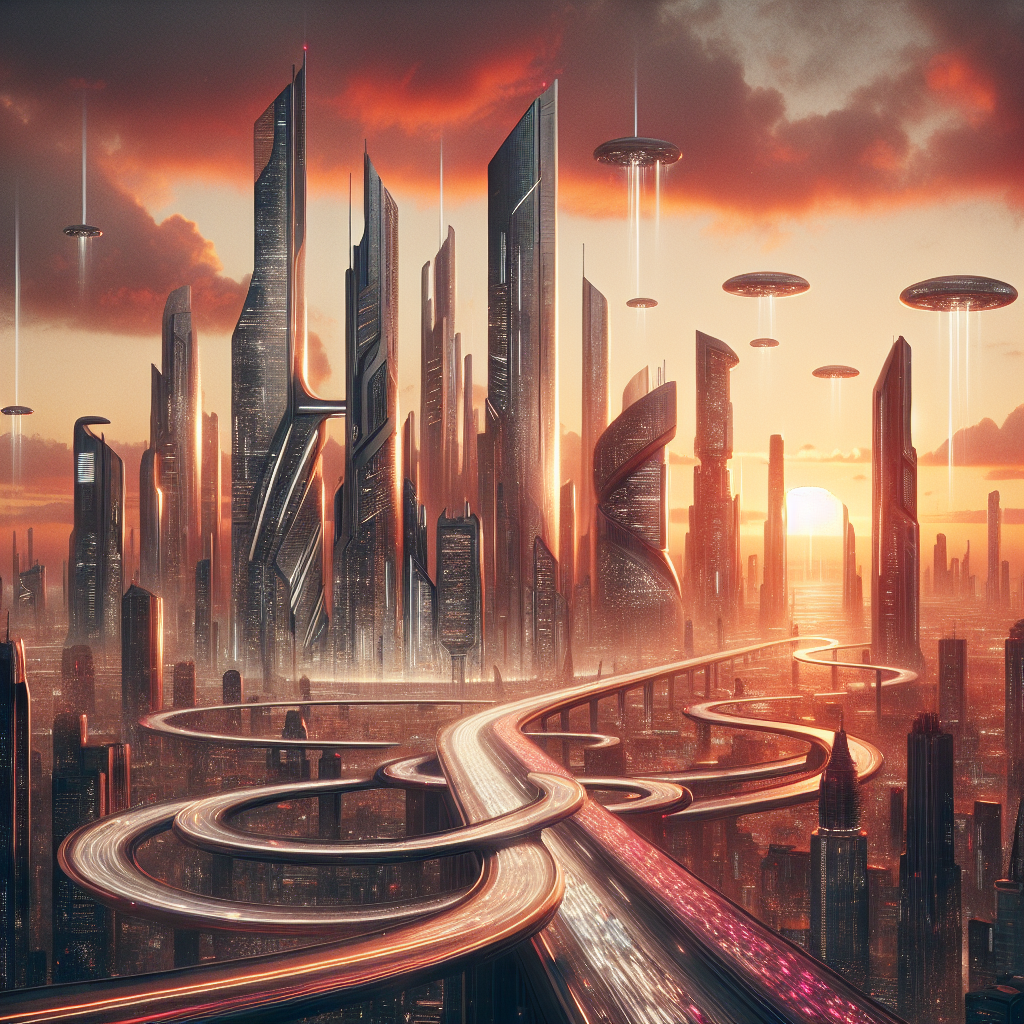

In [12]:
from litellm import image_generation
from IPython.display import Image, display
import requests

response = image_generation(
    model="dall-e-3",
    prompt="A futuristic city skyline at sunset, digital art style",
    n=1,
    size="1024x1024",
    quality="standard",
    style="vivid",
)

image_url = response.data[0].url
print(f"URL: {image_url[:80]}...")

img_data = requests.get(image_url).content
display(Image(data=img_data, width=400))

## 8. 👁️ Vision / Multimodal

In [13]:
from litellm import completion

response = completion(
    model="gpt-4o",
    messages=[{
        "role": "user",
        "content": [
            {"type": "text", "text": "Describe this image in 2 sentences."},
            {"type": "image_url", "image_url": {
                "url": "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png"
            }}
        ]
    }]
)
print("Vision:", response.choices[0].message.content)

Vision: The image features four translucent dice in different colors—red, green, blue, and yellow—each with white dots. The dice appear to be floating or levitating against a white background.


In [14]:
import base64, requests
from litellm import completion

img_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png"
img_b64 = base64.b64encode(requests.get(img_url).content).decode()

response = completion(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": [
        {"type": "text", "text": "What colors do you see?"},
        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}}
    ]}]
)
print("Base64 image:", response.choices[0].message.content)


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



BadRequestError: litellm.BadRequestError: OpenAIException - You uploaded an unsupported image. Please make sure your image has of one the following formats: ['png', 'jpeg', 'gif', 'webp'].

## 9. 🔧 Function Calling / Tool Use

In [15]:
import json
from litellm import completion

tools = [
    {"type": "function", "function": {
        "name": "get_weather",
        "description": "Get current weather for a city",
        "parameters": {"type": "object",
            "properties": {
                "city": {"type": "string"},
                "unit": {"type": "string", "enum": ["celsius", "fahrenheit"]}
            },
            "required": ["city"]}
    }},
    {"type": "function", "function": {
        "name": "calculate",
        "description": "Evaluate a math expression",
        "parameters": {"type": "object",
            "properties": {"expression": {"type": "string"}},
            "required": ["expression"]}
    }}
]

def get_weather(city, unit="celsius"):
    return {"city": city, "temp": 22, "unit": unit, "condition": "sunny"}

def calculate(expression):
    return {"result": eval(expression)}

messages = [{"role": "user", "content": "Weather in Paris and what is 15 * 7?"}]
response = completion(model="gpt-4o-mini", messages=messages, tools=tools, tool_choice="auto")
msg = response.choices[0].message
print(f"Finish reason: {response.choices[0].finish_reason}")
print(f"Tool calls: {len(msg.tool_calls or [])}")

messages.append(msg)
if msg.tool_calls:
    for tc in msg.tool_calls:
        fn_name = tc.function.name
        fn_args = json.loads(tc.function.arguments)
        print(f"\nCalling: {fn_name}({fn_args})")
        result = get_weather(**fn_args) if fn_name == "get_weather" else calculate(**fn_args)
        messages.append({"role": "tool", "tool_call_id": tc.id, "content": json.dumps(result)})

final = completion(model="gpt-4o-mini", messages=messages)
print("\nFinal answer:", final.choices[0].message.content)

Finish reason: tool_calls
Tool calls: 2

Calling: get_weather({'city': 'Paris'})

Calling: calculate({'expression': '15 * 7'})

Final answer: The weather in Paris is currently sunny with a temperature of 22°C. Also, 15 * 7 equals 105.


## 10. 📋 JSON Mode / Structured Outputs

In [16]:
import json
from litellm import completion

response = completion(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "Always respond with valid JSON."},
        {"role": "user", "content": "List 3 programming languages with year and use case."}
    ],
    response_format={"type": "json_object"}
)
parsed = json.loads(response.choices[0].message.content)
print(json.dumps(parsed, indent=2))

{
  "programming_languages": [
    {
      "language": "Python",
      "year_created": 1991,
      "use_case": "Web development, data analysis, artificial intelligence, scientific computing, automation."
    },
    {
      "language": "Java",
      "year_created": 1995,
      "use_case": "Enterprise applications, mobile applications (Android), web applications, big data technology."
    },
    {
      "language": "JavaScript",
      "year_created": 1995,
      "use_case": "Web development (client-side and server-side), interactive web applications, game development."
    }
  ]
}


In [17]:
from pydantic import BaseModel
from typing import List
from litellm import completion

class Language(BaseModel):
    name: str
    year: int
    use_case: str

class LanguageList(BaseModel):
    languages: List[Language]

response = completion(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "List 3 languages with year and use case."}],
    response_format=LanguageList,
)
result = LanguageList.model_validate_json(response.choices[0].message.content)
for lang in result.languages:
    print(f"  {lang.name} ({lang.year}): {lang.use_case}")

  Python (1991): Web development, data analysis, artificial intelligence, and scientific computing.
  JavaScript (1995): Front-end and back-end web development, mobile app development, and server-side programming.
  Java (1995): Enterprise applications, Android app development, and large-scale system development.


## 11. 💰 Cost Tracking & Token Usage

In [18]:
from litellm import completion, completion_cost
import litellm

response = completion(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Explain quantum computing in 3 sentences."}]
)

usage = response.usage
print(f"Prompt tokens:     {usage.prompt_tokens}")
print(f"Completion tokens: {usage.completion_tokens}")
print(f"Total tokens:      {usage.total_tokens}")

cost = completion_cost(completion_response=response)
print(f"\nEstimated cost: ${cost:.6f}")

cost2 = litellm.cost_per_token(
    model="gpt-4o-mini",
    prompt_tokens=usage.prompt_tokens,
    completion_tokens=usage.completion_tokens
)
print(f"Prompt cost:     ${cost2[0]:.8f}")
print(f"Completion cost: ${cost2[1]:.8f}")

Prompt tokens:     15
Completion tokens: 85
Total tokens:      100

Estimated cost: $0.000053
Prompt cost:     $0.00000225
Completion cost: $0.00005100


In [19]:
import litellm

messages = [{"role": "user", "content": "Write a short poem about the moon."}]
token_count = litellm.token_counter(model="gpt-4o-mini", messages=messages)
print(f"Estimated input tokens: {token_count}")

info = litellm.get_model_info("gpt-4o-mini")
print(f"\nModel info:")
print(f"  Context window: {info.get('max_tokens', 'N/A')} tokens")
print(f"  Input  $/1M:  ${(info.get('input_cost_per_token') or 0) * 1e6:.4f}")
print(f"  Output $/1M:  ${(info.get('output_cost_per_token') or 0) * 1e6:.4f}")

Estimated input tokens: 15

Model info:
  Context window: 16384 tokens
  Input  $/1M:  $0.1500
  Output $/1M:  $0.6000


## 12. 🛡️ Fallbacks & Retry Logic

In [20]:
import litellm
from litellm import completion

litellm.num_retries = 3
litellm.request_timeout = 30

try:
    response = completion(
        model="gpt-4o",
        messages=[{"role": "user", "content": "Hello!"}],
        fallbacks=["gpt-4o-mini"]   # fallback chain
    )
    print(f"Model used: {response.model}")
    print(f"Response:   {response.choices[0].message.content}")
except Exception as e:
    print(f"All models failed: {e}")

Model used: gpt-4o-2024-08-06
Response:   Hi there! How can I assist you today?


In [21]:
# Context window fallback
from litellm import completion

try:
    response = completion(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": "Hello world"}],
        context_window_fallback_dict={"gpt-3.5-turbo": "gpt-4-turbo"}
    )
    print(f"Used: {response.model}")
    print(f"Resp: {response.choices[0].message.content}")
except Exception as e:
    print(f"Error: {e}")

Used: gpt-3.5-turbo-0125
Resp: Hello! How are you today?


## 13. 🗺️ Router — Load Balancing

In [22]:
from litellm import Router
import os

model_list = [
    {
        "model_name": "fast-model",
        "litellm_params": {
            "model": "gpt-4o-mini",
            "api_key": os.environ.get("OPENAI_API_KEY"),
        },
        "tpm": 100000,
        "rpm": 1000,
    },
    # Add more deployments for real load balancing
]

router = Router(
    model_list=model_list,
    routing_strategy="usage-based-routing",
    num_retries=2,
    timeout=30,
    allowed_fails=3,
    cooldown_time=60,
)

response = router.completion(
    model="fast-model",
    messages=[{"role": "user", "content": "What is the speed of light?"}]
)
print(f"Router ({response.model}):")
print(response.choices[0].message.content)

Router (gpt-4o-mini-2024-07-18):
The speed of light in a vacuum is approximately \(299,792,458\) meters per second (m/s), which is often rounded to \(3.00 \times 10^8\) m/s for simplicity in calculations. This speed is fundamental in physics and is denoted by the symbol \(c\).


---
## 🎉 Summary — LiteLLM Feature Map

| Feature | Section | Key API |
|---|---|---|
| Multi-provider completions | 3 | `litellm.completion()` |
| Streaming | 4 | `stream=True` |
| Async / parallel | 5 | `litellm.acompletion()` |
| Embeddings | 6 | `litellm.embedding()` |
| Image generation | 7 | `litellm.image_generation()` |
| Vision / multimodal | 8 | Image content blocks |
| Function / tool calling | 9 | `tools=` parameter |
| JSON / structured output | 10 | `response_format=` |
| Cost tracking | 11 | `litellm.completion_cost()` |
| Fallbacks & retries | 12 | `fallbacks=`, `num_retries=` |
| Router / load balancing | 13 | `Router` class |
| Caching | 14 | `litellm.cache = Cache(...)` |
| Logging & observability | 15 | `litellm.success_callback` |
| Guardrails | 16 | `litellm.moderation()` |
| Batch completions | 17 | `asyncio.gather()` |
| Prompt & chat management | 18 | History list |
| Model aliases | 19 | `litellm.model_alias_map` |
| Budget manager | 20 | `BudgetManager` |
| Timeout & errors | 21 | `timeout=`, exception types |
| OpenAI drop-in | 22 | `from litellm import OpenAI` |
| Text completion | 23 | `litellm.text_completion()` |
| TTS & Whisper | 24 | `litellm.speech()` / `transcription()` |
| Cloud providers | 25 | `azure/` `bedrock/` `vertex_ai/` |
| Proxy / AI gateway | 26 | `litellm --config config.yaml` |
| Model info | 27 | `litellm.get_model_info()` |

---
> 📚 Docs: https://docs.litellm.ai  
> 💻 GitHub: https://github.com/BerriAI/litellm